## Traffic Sign Detection using EfficentNet Algorithm



The code mounts Google Drive to your Google Colab environment, allowing you to access files stored on your Google Drive directly within the Colab notebook. Once mounted, the files will be accessible under the /content/drive directory.

In [9]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Google Drive mounted (Colab).')
except Exception:
    print('Not running in Google Colab. Skipping drive mount.')

Not running in Google Colab. Skipping drive mount.


In [10]:
!pip install pipreqs

In [11]:
!pip freeze > requirements.txt

In [12]:
import importlib
import subprocess
import sys

# CPU-only setup: avoid Colab-specific or GPU-related package sources.
required = ["efficientnet_pytorch", "tensorboardX"]
for pkg in required:
    try:
        importlib.import_module(pkg)
        print(f"{pkg} already installed")
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

efficientnet_pytorch already installed
tensorboardX already installed


In [13]:
# Optional in this local workflow; all required code exists in this notebook.
print("Skipping external repo clone.")

Skipping external repo clone.


In [14]:
# CPU-only PyTorch install (no CUDA/GPU build)
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu
%pip install pycocotools opencv-python matplotlib tqdm flask flask-ngrok pyngrok

Looking in indexes: https://download.pytorch.org/whl/cpu
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# Dataset Preparation

This code defines a custom PyTorch Dataset class (CocoDataset) for working with the COCO dataset, along with utilities for data augmentation, normalization, resizing, and batching. Here's a brief explanation of its key components:

CocoDataset Class:

Handles loading images and annotations from the COCO dataset.
Supports transformations to preprocess the data.
Implements functionality to convert COCO-style annotations into [x1, y1, x2, y2, class] format.
Transforms:

Resizer: Resizes images to a common size (default 512) while preserving aspect ratio and scaling annotations accordingly.
Augmenter: Applies random horizontal flipping for data augmentation.
Normalizer: Normalizes images using ImageNet's mean and standard deviation values.
Batching:

collater: Prepares batches of data for training, including padding annotations to a uniform size across all images in the batch.

In [15]:
import os
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from pycocotools.coco import COCO
import cv2
class CocoDataset(Dataset):
    def __init__(self, root_dir, img_dir="images", set_dir='train2017', transform=None):

        self.root_dir = root_dir
        self.img_dir = img_dir
        self.set_name = set_dir
        self.transform = transform

        split_dir = self.set_name.strip('/\\')
        split_annotation = os.path.join(self.root_dir, split_dir, '_annotations.coco.json')
        if os.path.exists(split_annotation):
            # Roboflow-style COCO: <root>/<split>/_annotations.coco.json + images in same split folder.
            self.images_dir = os.path.join(self.root_dir, split_dir)
            annotation_file = split_annotation
        else:
            # Classic COCO: <root>/annotations/instances_<split>.json + images in <img_dir>/<split>.
            self.images_dir = os.path.join(self.root_dir, self.img_dir, self.set_name)
            annotation_file = os.path.join(self.root_dir, 'annotations', 'instances_' + self.set_name + '.json')

        self.coco = COCO(annotation_file)
        self.image_ids = self.coco.getImgIds()

        self.load_classes()

    def load_classes(self):

        # load class names (name -> label)
        categories = self.coco.loadCats(self.coco.getCatIds())
        categories.sort(key=lambda x: x['id'])

        self.classes = {}
        self.coco_labels = {}
        self.coco_labels_inverse = {}
        for c in categories:
            self.coco_labels[len(self.classes)] = c['id']
            self.coco_labels_inverse[c['id']] = len(self.classes)
            self.classes[c['name']] = len(self.classes)

        # also load the reverse (label -> name)
        self.labels = {}
        for key, value in self.classes.items():
            self.labels[value] = key

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):

        img = self.load_image(idx)
        annot = self.load_annotations(idx)
        sample = {'img': img, 'annot': annot}
        if self.transform:
            sample = self.transform(sample)
        return sample

    def load_image(self, image_index):
        image_info = self.coco.loadImgs(self.image_ids[image_index])[0]
        path = os.path.join(self.images_dir, image_info['file_name'])
        img = cv2.imread(path)
        if img is None:
            raise FileNotFoundError(f"Could not read image at: {path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        return img.astype(np.float32) / 255.

    def load_annotations(self, image_index):
        # get ground truth annotations
        annotations_ids = self.coco.getAnnIds(imgIds=self.image_ids[image_index], iscrowd=False)
        annotations = np.zeros((0, 5))

        # some images appear to miss annotations
        if len(annotations_ids) == 0:
            return annotations

        # parse annotations
        coco_annotations = self.coco.loadAnns(annotations_ids)
        for idx, a in enumerate(coco_annotations):

            # some annotations have basically no width / height, skip them
            if a['area'] == 0:
                continue

            if a['bbox'][2] < 1 or a['bbox'][3] < 1:
                continue

            annotation = np.zeros((1, 5))
            annotation[0, :4] = a['bbox']
            annotation[0, 4] = self.coco_label_to_label(a['category_id'])
            annotations = np.append(annotations, annotation, axis=0)

        # transform from [x, y, w, h] to [x1, y1, x2, y2]
        annotations[:, 2] = annotations[:, 0] + annotations[:, 2]
        annotations[:, 3] = annotations[:, 1] + annotations[:, 3]

        return annotations

    def coco_label_to_label(self, coco_label):
        return self.coco_labels_inverse[coco_label]

    def label_to_coco_label(self, label):
        return self.coco_labels[label]

    def num_classes(self):
        return len(self.classes)


def collater(data):
    imgs = [s['img'] for s in data]
    annots = [s['annot'] for s in data]
    scales = [s['scale'] for s in data]

    imgs = torch.from_numpy(np.stack(imgs, axis=0))

    max_num_annots = max(annot.shape[0] for annot in annots)

    if max_num_annots > 0:

        annot_padded = torch.ones((len(annots), max_num_annots, 5)) * -1

        if max_num_annots > 0:
            for idx, annot in enumerate(annots):
                if annot.shape[0] > 0:
                    annot_padded[idx, :annot.shape[0], :] = annot
    else:
        annot_padded = torch.ones((len(annots), 1, 5)) * -1

    imgs = imgs.permute(0, 3, 1, 2)

    return {'img': imgs, 'annot': annot_padded, 'scale': scales}


class Resizer(object):
    """Convert ndarrays in sample to Tensors."""

    def __call__(self, sample, common_size=512):
        image, annots = sample['img'], sample['annot']
        height, width, _ = image.shape
        if height > width:
            scale = common_size / height
            resized_height = common_size
            resized_width = int(width * scale)
        else:
            scale = common_size / width
            resized_height = int(height * scale)
            resized_width = common_size

        image = cv2.resize(image, (resized_width, resized_height))

        new_image = np.zeros((common_size, common_size, 3))
        new_image[0:resized_height, 0:resized_width] = image

        annots[:, :4] *= scale

        return {'img': torch.from_numpy(new_image), 'annot': torch.from_numpy(annots), 'scale': scale}


class Augmenter(object):
    """Convert ndarrays in sample to Tensors."""

    def __call__(self, sample, flip_x=0.5):
        if np.random.rand() < flip_x:
            image, annots = sample['img'], sample['annot']
            image = image[:, ::-1, :]

            rows, cols, channels = image.shape

            x1 = annots[:, 0].copy()
            x2 = annots[:, 2].copy()

            x_tmp = x1.copy()

            annots[:, 0] = cols - x2
            annots[:, 2] = cols - x_tmp

            sample = {'img': image, 'annot': annots}

        return sample


class Normalizer(object):

    def __init__(self):
        self.mean = np.array([[[0.485, 0.456, 0.406]]])
        self.std = np.array([[[0.229, 0.224, 0.225]]])

    def __call__(self, sample):
        image, annots = sample['img'], sample['annot']

        return {'img': ((image.astype(np.float32) - self.mean) / self.std), 'annot': annots}

# UTILS

The code you provided implements core modules used in object detection frameworks, particularly for anchor-based models. Here's a breakdown of its key components:



1. BBoxTransform
Purpose: Adjust bounding boxes based on network output (deltas).
Key Elements:
Computes center (ctr_x, ctr_y), width, and height of the input boxes.
Adjusts these values using deltas scaled by the mean and standard deviation.
Constructs new bounding boxes (pred_boxes) based on the adjusted dimensions.

2. ClipBoxes
Purpose: Ensures bounding boxes stay within image boundaries.
Key Elements:
Clamps box coordinates to be non-negative and ensures they do not exceed the image's dimensions.

3. Anchors
Purpose: Generates a set of anchor boxes over different pyramid levels of the feature map.
Key Elements:
Computes sizes and strides for each pyramid level.
Uses generate_anchors and shift to create anchors at specific spatial locations.
Outputs all anchors in a single tensor.

4. Helper Functions
generate_anchors
Purpose: Generates anchor boxes for a given base size, set of aspect ratios, and scales.
Key Elements:
Adjusts widths and heights based on scales and aspect ratios.
Anchors are centered around (0, 0).
compute_shape
Purpose: Computes the feature map shapes at different pyramid levels based on the input image dimensions.
shift
Purpose: Places anchor boxes across all locations of the feature map.
Key Elements:
Computes shifts (grid offsets) across the feature map.
Adds these shifts to the base anchors to create anchors for every location.

In [16]:
import torch

import torch.nn as nn
import numpy as np
class BBoxTransform(nn.Module):

    def __init__(self, mean=None, std=None):
        super(BBoxTransform, self).__init__()
        if mean is None:
            self.mean = torch.from_numpy(np.array([0, 0, 0, 0]).astype(np.float32))
        else:
            self.mean = mean
        if std is None:
            self.std = torch.from_numpy(np.array([0.1, 0.1, 0.2, 0.2]).astype(np.float32))
        else:
            self.std = std
        if torch.cuda.is_available():
            self.mean = self.mean.cuda()
            self.std = self.std.cuda()

    def forward(self, boxes, deltas):

        widths = boxes[:, :, 2] - boxes[:, :, 0]
        heights = boxes[:, :, 3] - boxes[:, :, 1]
        ctr_x = boxes[:, :, 0] + 0.5 * widths
        ctr_y = boxes[:, :, 1] + 0.5 * heights

        dx = deltas[:, :, 0] * self.std[0] + self.mean[0]
        dy = deltas[:, :, 1] * self.std[1] + self.mean[1]
        dw = deltas[:, :, 2] * self.std[2] + self.mean[2]
        dh = deltas[:, :, 3] * self.std[3] + self.mean[3]

        pred_ctr_x = ctr_x + dx * widths
        pred_ctr_y = ctr_y + dy * heights
        pred_w = torch.exp(dw) * widths
        pred_h = torch.exp(dh) * heights

        pred_boxes_x1 = pred_ctr_x - 0.5 * pred_w
        pred_boxes_y1 = pred_ctr_y - 0.5 * pred_h
        pred_boxes_x2 = pred_ctr_x + 0.5 * pred_w
        pred_boxes_y2 = pred_ctr_y + 0.5 * pred_h

        pred_boxes = torch.stack([pred_boxes_x1, pred_boxes_y1, pred_boxes_x2, pred_boxes_y2], dim=2)

        return pred_boxes


class ClipBoxes(nn.Module):

    def __init__(self):
        super(ClipBoxes, self).__init__()

    def forward(self, boxes, img):
        batch_size, num_channels, height, width = img.shape

        boxes[:, :, 0] = torch.clamp(boxes[:, :, 0], min=0)
        boxes[:, :, 1] = torch.clamp(boxes[:, :, 1], min=0)

        boxes[:, :, 2] = torch.clamp(boxes[:, :, 2], max=width)
        boxes[:, :, 3] = torch.clamp(boxes[:, :, 3], max=height)

        return boxes


class Anchors(nn.Module):
    def __init__(self, pyramid_levels=None, strides=None, sizes=None, ratios=None, scales=None):
        super(Anchors, self).__init__()

        if pyramid_levels is None:
            self.pyramid_levels = [3, 4, 5, 6, 7]
        if strides is None:
            self.strides = [2 ** x for x in self.pyramid_levels]
        if sizes is None:
            self.sizes = [2 ** (x + 2) for x in self.pyramid_levels]
        if ratios is None:
            self.ratios = np.array([0.5, 1, 2])
        if scales is None:
            self.scales = np.array([2 ** 0, 2 ** (1.0 / 3.0), 2 ** (2.0 / 3.0)])

    def forward(self, image):

        image_shape = image.shape[2:]
        image_shape = np.array(image_shape)
        image_shapes = [(image_shape + 2 ** x - 1) // (2 ** x) for x in self.pyramid_levels]

        all_anchors = np.zeros((0, 4)).astype(np.float32)

        for idx, p in enumerate(self.pyramid_levels):
            anchors = generate_anchors(base_size=self.sizes[idx], ratios=self.ratios, scales=self.scales)
            shifted_anchors = shift(image_shapes[idx], self.strides[idx], anchors)
            all_anchors = np.append(all_anchors, shifted_anchors, axis=0)

        all_anchors = np.expand_dims(all_anchors, axis=0)

        anchors = torch.from_numpy(all_anchors.astype(np.float32))
        if torch.cuda.is_available():
            anchors = anchors.cuda()
        return anchors


def generate_anchors(base_size=16, ratios=None, scales=None):
    if ratios is None:
        ratios = np.array([0.5, 1, 2])

    if scales is None:
        scales = np.array([2 ** 0, 2 ** (1.0 / 3.0), 2 ** (2.0 / 3.0)])

    num_anchors = len(ratios) * len(scales)
    anchors = np.zeros((num_anchors, 4))
    anchors[:, 2:] = base_size * np.tile(scales, (2, len(ratios))).T
    areas = anchors[:, 2] * anchors[:, 3]
    anchors[:, 2] = np.sqrt(areas / np.repeat(ratios, len(scales)))
    anchors[:, 3] = anchors[:, 2] * np.repeat(ratios, len(scales))
    anchors[:, 0::2] -= np.tile(anchors[:, 2] * 0.5, (2, 1)).T
    anchors[:, 1::2] -= np.tile(anchors[:, 3] * 0.5, (2, 1)).T

    return anchors


def compute_shape(image_shape, pyramid_levels):
    image_shape = np.array(image_shape[:2])
    image_shapes = [(image_shape + 2 ** x - 1) // (2 ** x) for x in pyramid_levels]
    return image_shapes


def shift(shape, stride, anchors):
    shift_x = (np.arange(0, shape[1]) + 0.5) * stride
    shift_y = (np.arange(0, shape[0]) + 0.5) * stride
    shift_x, shift_y = np.meshgrid(shift_x, shift_y)
    shifts = np.vstack((
        shift_x.ravel(), shift_y.ravel(),
        shift_x.ravel(), shift_y.ravel()
    )).transpose()

    A = anchors.shape[0]
    K = shifts.shape[0]
    all_anchors = (anchors.reshape((1, A, 4)) + shifts.reshape((1, K, 4)).transpose((1, 0, 2)))
    all_anchors = all_anchors.reshape((K * A, 4))

    return all_anchors


# LOSS

This code implements a custom Focal Loss for object detection tasks, designed to handle imbalanced classification problems commonly encountered in such tasks. Here's an overview of the key components and functionality:


Key Functions and Classes
calc_iou(a, b):

Computes the Intersection over Union (IoU) between two sets of bounding boxes, a and b.
Used to assign ground truth annotations to anchors based on IoU thresholds.

**FocalLoss Class:**

Inherits from nn.Module.
Implements the Focal Loss for classification and Smooth L1 loss for regression.
Focal Loss Components

**Alpha Factor (alpha):**

Balances the importance of positive vs. negative samples.
A typical value is 0.25.
Gamma (gamma):

Modulates the loss by focusing on hard-to-classify examples.
A typical value is 2.0.

**Positive and Negative Anchors:**

Anchors with IoU ≥ 0.5 are positive; those with IoU < 0.4 are negative.
Targets are set to 1 for the positive class, 0 for all other classes, and -1 for ignored anchors.

**Loss Calculation:**

Binary Cross Entropy (BCE) is modified using the focal weight:
focal_weight
=
𝛼
⋅
(
1
−
𝑝
𝑡
)
𝛾
focal_weight=α⋅(1−p
t
​
 )
γ

p_t is the predicted probability for the ground truth class.
Regression Loss
The regression loss uses a Smooth L1 function:
𝐿
1
𝑠
𝑚
𝑜
𝑜
𝑡
ℎ
=
{
0.5
⋅
(
𝑥
)
2
if
∣
𝑥
∣
<
1
9
∣
𝑥
∣
−
0.5
otherwise
L1
smooth
​
 ={
0.5⋅(x)
2

∣x∣−0.5
​
  
if ∣x∣<
9
1
​

otherwise
​

Regression targets are normalized using the norm tensor [0.1, 0.1, 0.2, 0.2].
Workflow

**Input Dimensions:**


**classifications:** Predicted class probabilities (Batch x Anchors x Classes).
regressions: Predicted bounding box adjustments (Batch x Anchors x 4).
anchors: Pre-defined anchor boxes (1 x Anchors x 4).
annotations: Ground truth annotations (Batch x Max Objects x 5).

**IoU Computation:**

Calculate IoU between anchors and ground truth boxes.
Assign ground truth to anchors based on IoU thresholds.

**Classification Loss:**

Compute BCE with focal weighting for all anchors.
Ignore anchors marked as -1.

Regression Loss:
Compute the Smooth L1 loss for positive anchors only.
Outputs:

Mean classification loss and regression loss for the batch.
Advantages
Focus on Hard Examples:
Reduces the contribution of well-classified examples, focusing on difficult ones.
Supports Multi-class Detection:
Handles multiple classes using one-hot encoding for ground truth.


In [17]:
import torch
import torch.nn as nn
def calc_iou(a, b):

    area = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])
    iw = torch.min(torch.unsqueeze(a[:, 2], dim=1), b[:, 2]) - torch.max(torch.unsqueeze(a[:, 0], 1), b[:, 0])
    ih = torch.min(torch.unsqueeze(a[:, 3], dim=1), b[:, 3]) - torch.max(torch.unsqueeze(a[:, 1], 1), b[:, 1])
    iw = torch.clamp(iw, min=0)
    ih = torch.clamp(ih, min=0)
    ua = torch.unsqueeze((a[:, 2] - a[:, 0]) * (a[:, 3] - a[:, 1]), dim=1) + area - iw * ih
    ua = torch.clamp(ua, min=1e-8)
    intersection = iw * ih
    IoU = intersection / ua

    return IoU


class FocalLoss(nn.Module):
    def __init__(self):
        super(FocalLoss, self).__init__()

    def forward(self, classifications, regressions, anchors, annotations):
        alpha = 0.25
        gamma = 2.0
        batch_size = classifications.shape[0]
        classification_losses = []
        regression_losses = []

        anchor = anchors[0, :, :]

        anchor_widths = anchor[:, 2] - anchor[:, 0]
        anchor_heights = anchor[:, 3] - anchor[:, 1]
        anchor_ctr_x = anchor[:, 0] + 0.5 * anchor_widths
        anchor_ctr_y = anchor[:, 1] + 0.5 * anchor_heights

        for j in range(batch_size):

            classification = classifications[j, :, :]
            regression = regressions[j, :, :]

            bbox_annotation = annotations[j, :, :]
            bbox_annotation = bbox_annotation[bbox_annotation[:, 4] != -1]

            if bbox_annotation.shape[0] == 0:
                if torch.cuda.is_available():
                    regression_losses.append(torch.tensor(0).float().cuda())
                    classification_losses.append(torch.tensor(0).float().cuda())
                else:
                    regression_losses.append(torch.tensor(0).float())
                    classification_losses.append(torch.tensor(0).float())

                continue

            classification = torch.clamp(classification, 1e-4, 1.0 - 1e-4)

            IoU = calc_iou(anchors[0, :, :], bbox_annotation[:, :4])

            IoU_max, IoU_argmax = torch.max(IoU, dim=1)

            # compute the loss for classification
            targets = torch.ones(classification.shape) * -1
            if torch.cuda.is_available():
                targets = targets.cuda()

            targets[torch.lt(IoU_max, 0.4), :] = 0

            positive_indices = torch.ge(IoU_max, 0.5)

            num_positive_anchors = positive_indices.sum()

            assigned_annotations = bbox_annotation[IoU_argmax, :]

            targets[positive_indices, :] = 0
            targets[positive_indices, assigned_annotations[positive_indices, 4].long()] = 1

            alpha_factor = torch.ones(targets.shape) * alpha
            if torch.cuda.is_available():
                alpha_factor = alpha_factor.cuda()

            alpha_factor = torch.where(torch.eq(targets, 1.), alpha_factor, 1. - alpha_factor)
            focal_weight = torch.where(torch.eq(targets, 1.), 1. - classification, classification)
            focal_weight = alpha_factor * torch.pow(focal_weight, gamma)

            bce = -(targets * torch.log(classification) + (1.0 - targets) * torch.log(1.0 - classification))

            cls_loss = focal_weight * bce

            zeros = torch.zeros(cls_loss.shape)
            if torch.cuda.is_available():
                zeros = zeros.cuda()
            cls_loss = torch.where(torch.ne(targets, -1.0), cls_loss, zeros)

            classification_losses.append(cls_loss.sum() / torch.clamp(num_positive_anchors.float(), min=1.0))


            if positive_indices.sum() > 0:
                assigned_annotations = assigned_annotations[positive_indices, :]

                anchor_widths_pi = anchor_widths[positive_indices]
                anchor_heights_pi = anchor_heights[positive_indices]
                anchor_ctr_x_pi = anchor_ctr_x[positive_indices]
                anchor_ctr_y_pi = anchor_ctr_y[positive_indices]

                gt_widths = assigned_annotations[:, 2] - assigned_annotations[:, 0]
                gt_heights = assigned_annotations[:, 3] - assigned_annotations[:, 1]
                gt_ctr_x = assigned_annotations[:, 0] + 0.5 * gt_widths
                gt_ctr_y = assigned_annotations[:, 1] + 0.5 * gt_heights

                gt_widths = torch.clamp(gt_widths, min=1)
                gt_heights = torch.clamp(gt_heights, min=1)

                targets_dx = (gt_ctr_x - anchor_ctr_x_pi) / anchor_widths_pi
                targets_dy = (gt_ctr_y - anchor_ctr_y_pi) / anchor_heights_pi
                targets_dw = torch.log(gt_widths / anchor_widths_pi)
                targets_dh = torch.log(gt_heights / anchor_heights_pi)

                targets = torch.stack((targets_dx, targets_dy, targets_dw, targets_dh))
                targets = targets.t()

                norm = torch.Tensor([[0.1, 0.1, 0.2, 0.2]])
                if torch.cuda.is_available():
                    norm = norm.cuda()
                targets = targets / norm

                regression_diff = torch.abs(targets - regression[positive_indices, :])

                regression_loss = torch.where(
                    torch.le(regression_diff, 1.0 / 9.0),
                    0.5 * 9.0 * torch.pow(regression_diff, 2),
                    regression_diff - 0.5 / 9.0
                )
                regression_losses.append(regression_loss.mean())
            else:
                if torch.cuda.is_available():
                    regression_losses.append(torch.tensor(0).float().cuda())
                else:
                    regression_losses.append(torch.tensor(0).float())

        return torch.stack(classification_losses).mean(dim=0, keepdim=True), torch.stack(regression_losses).mean(dim=0,
                                                                                                                 keepdim=True)


# MODEL

In [18]:
import torch.nn as nn
import torch
import math
from efficientnet_pytorch import EfficientNet as EffNet
from torchvision.ops.boxes import nms as nms_torch


def nms(dets, thresh):
    return nms_torch(dets[:, :4], dets[:, 4], thresh)


class ConvBlock(nn.Module):
    def __init__(self, num_channels):
        super(ConvBlock, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(num_channels, num_channels, kernel_size=3, stride=1, padding=1, groups=num_channels),
            nn.Conv2d(num_channels, num_channels, kernel_size=1, stride=1, padding=0),
            nn.BatchNorm2d(num_features=num_channels, momentum=0.9997, eps=4e-5), nn.ReLU())

    def forward(self, input):
        return self.conv(input)


class BiFPN(nn.Module):
    def __init__(self, num_channels, epsilon=1e-4):
        super(BiFPN, self).__init__()
        self.epsilon = epsilon
        # Conv layers
        self.conv6_up = ConvBlock(num_channels)
        self.conv5_up = ConvBlock(num_channels)
        self.conv4_up = ConvBlock(num_channels)
        self.conv3_up = ConvBlock(num_channels)
        self.conv4_down = ConvBlock(num_channels)
        self.conv5_down = ConvBlock(num_channels)
        self.conv6_down = ConvBlock(num_channels)
        self.conv7_down = ConvBlock(num_channels)

        # Feature scaling layers
        self.p6_upsample = nn.Upsample(scale_factor=2, mode='nearest')
        self.p5_upsample = nn.Upsample(scale_factor=2, mode='nearest')
        self.p4_upsample = nn.Upsample(scale_factor=2, mode='nearest')
        self.p3_upsample = nn.Upsample(scale_factor=2, mode='nearest')

        self.p4_downsample = nn.MaxPool2d(kernel_size=2)
        self.p5_downsample = nn.MaxPool2d(kernel_size=2)
        self.p6_downsample = nn.MaxPool2d(kernel_size=2)
        self.p7_downsample = nn.MaxPool2d(kernel_size=2)

        # Weight
        self.p6_w1 = nn.Parameter(torch.ones(2))
        self.p6_w1_relu = nn.ReLU()
        self.p5_w1 = nn.Parameter(torch.ones(2))
        self.p5_w1_relu = nn.ReLU()
        self.p4_w1 = nn.Parameter(torch.ones(2))
        self.p4_w1_relu = nn.ReLU()
        self.p3_w1 = nn.Parameter(torch.ones(2))
        self.p3_w1_relu = nn.ReLU()

        self.p4_w2 = nn.Parameter(torch.ones(3))
        self.p4_w2_relu = nn.ReLU()
        self.p5_w2 = nn.Parameter(torch.ones(3))
        self.p5_w2_relu = nn.ReLU()
        self.p6_w2 = nn.Parameter(torch.ones(3))
        self.p6_w2_relu = nn.ReLU()
        self.p7_w2 = nn.Parameter(torch.ones(2))
        self.p7_w2_relu = nn.ReLU()

    def forward(self, inputs):
        """
            P7_0 -------------------------- P7_2 -------->

            P6_0 ---------- P6_1 ---------- P6_2 -------->

            P5_0 ---------- P5_1 ---------- P5_2 -------->

            P4_0 ---------- P4_1 ---------- P4_2 -------->

            P3_0 -------------------------- P3_2 -------->
        """

        # P3_0, P4_0, P5_0, P6_0 and P7_0
        p3_in, p4_in, p5_in, p6_in, p7_in = inputs
        # P7_0 to P7_2
        # Weights for P6_0 and P7_0 to P6_1
        p6_w1 = self.p6_w1_relu(self.p6_w1)
        weight = p6_w1 / (torch.sum(p6_w1, dim=0) + self.epsilon)
        # Connections for P6_0 and P7_0 to P6_1 respectively
        p6_up = self.conv6_up(weight[0] * p6_in + weight[1] * self.p6_upsample(p7_in))
        # Weights for P5_0 and P6_0 to P5_1
        p5_w1 = self.p5_w1_relu(self.p5_w1)
        weight = p5_w1 / (torch.sum(p5_w1, dim=0) + self.epsilon)
        # Connections for P5_0 and P6_0 to P5_1 respectively
        p5_up = self.conv5_up(weight[0] * p5_in + weight[1] * self.p5_upsample(p6_up))
        # Weights for P4_0 and P5_0 to P4_1
        p4_w1 = self.p4_w1_relu(self.p4_w1)
        weight = p4_w1 / (torch.sum(p4_w1, dim=0) + self.epsilon)
        # Connections for P4_0 and P5_0 to P4_1 respectively
        p4_up = self.conv4_up(weight[0] * p4_in + weight[1] * self.p4_upsample(p5_up))

        # Weights for P3_0 and P4_1 to P3_2
        p3_w1 = self.p3_w1_relu(self.p3_w1)
        weight = p3_w1 / (torch.sum(p3_w1, dim=0) + self.epsilon)
        # Connections for P3_0 and P4_1 to P3_2 respectively
        p3_out = self.conv3_up(weight[0] * p3_in + weight[1] * self.p3_upsample(p4_up))

        # Weights for P4_0, P4_1 and P3_2 to P4_2
        p4_w2 = self.p4_w2_relu(self.p4_w2)
        weight = p4_w2 / (torch.sum(p4_w2, dim=0) + self.epsilon)
        # Connections for P4_0, P4_1 and P3_2 to P4_2 respectively
        p4_out = self.conv4_down(
            weight[0] * p4_in + weight[1] * p4_up + weight[2] * self.p4_downsample(p3_out))
        # Weights for P5_0, P5_1 and P4_2 to P5_2
        p5_w2 = self.p5_w2_relu(self.p5_w2)
        weight = p5_w2 / (torch.sum(p5_w2, dim=0) + self.epsilon)
        # Connections for P5_0, P5_1 and P4_2 to P5_2 respectively
        p5_out = self.conv5_down(
            weight[0] * p5_in + weight[1] * p5_up + weight[2] * self.p5_downsample(p4_out))
        # Weights for P6_0, P6_1 and P5_2 to P6_2
        p6_w2 = self.p6_w2_relu(self.p6_w2)
        weight = p6_w2 / (torch.sum(p6_w2, dim=0) + self.epsilon)
        # Connections for P6_0, P6_1 and P5_2 to P6_2 respectively
        p6_out = self.conv6_down(
            weight[0] * p6_in + weight[1] * p6_up + weight[2] * self.p6_downsample(p5_out))
        # Weights for P7_0 and P6_2 to P7_2
        p7_w2 = self.p7_w2_relu(self.p7_w2)
        weight = p7_w2 / (torch.sum(p7_w2, dim=0) + self.epsilon)
        # Connections for P7_0 and P6_2 to P7_2
        p7_out = self.conv7_down(weight[0] * p7_in + weight[1] * self.p7_downsample(p6_out))

        return p3_out, p4_out, p5_out, p6_out, p7_out


class Regressor(nn.Module):
    def __init__(self, in_channels, num_anchors, num_layers):
        super(Regressor, self).__init__()
        layers = []
        for _ in range(num_layers):
            layers.append(nn.Conv2d(in_channels, in_channels, kernel_size=3, stride=1, padding=1))
            layers.append(nn.ReLU(True))
        self.layers = nn.Sequential(*layers)
        self.header = nn.Conv2d(in_channels, num_anchors * 4, kernel_size=3, stride=1, padding=1)

    def forward(self, inputs):
        inputs = self.layers(inputs)
        inputs = self.header(inputs)
        output = inputs.permute(0, 2, 3, 1)
        return output.contiguous().view(output.shape[0], -1, 4)


class Classifier(nn.Module):
    def __init__(self, in_channels, num_anchors, num_classes, num_layers):
        super(Classifier, self).__init__()
        self.num_anchors = num_anchors
        self.num_classes = num_classes
        layers = []
        for _ in range(num_layers):
            layers.append(nn.Conv2d(in_channels, in_channels, kernel_size=3, stride=1, padding=1))
            layers.append(nn.ReLU(True))
        self.layers = nn.Sequential(*layers)
        self.header = nn.Conv2d(in_channels, num_anchors * num_classes, kernel_size=3, stride=1, padding=1)
        self.act = nn.Sigmoid()

    def forward(self, inputs):
        inputs = self.layers(inputs)
        inputs = self.header(inputs)
        inputs = self.act(inputs)
        inputs = inputs.permute(0, 2, 3, 1)
        output = inputs.contiguous().view(inputs.shape[0], inputs.shape[1], inputs.shape[2], self.num_anchors,
                                          self.num_classes)
        return output.contiguous().view(output.shape[0], -1, self.num_classes)


class EfficientNet(nn.Module):
    def __init__(self, ):
        super(EfficientNet, self).__init__()
        model = EffNet.from_pretrained('efficientnet-b0')
        del model._conv_head
        del model._bn1
        del model._avg_pooling
        del model._dropout
        del model._fc
        self.model = model

    def forward(self, x):
        x = self.model._swish(self.model._bn0(self.model._conv_stem(x)))
        feature_maps = []
        for idx, block in enumerate(self.model._blocks):
            drop_connect_rate = self.model._global_params.drop_connect_rate
            if drop_connect_rate:
                drop_connect_rate *= float(idx) / len(self.model._blocks)
            x = block(x, drop_connect_rate=drop_connect_rate)
            if block._depthwise_conv.stride == [2, 2]:
                feature_maps.append(x)

        return feature_maps[1:]


class EfficientDet(nn.Module):
    def __init__(self, num_anchors=9, num_classes=20, compound_coef=0):
        super(EfficientDet, self).__init__()
        self.compound_coef = compound_coef

        self.num_channels = [64, 88, 112, 160, 224, 288, 384, 384][self.compound_coef]

        self.conv3 = nn.Conv2d(40, self.num_channels, kernel_size=1, stride=1, padding=0)
        self.conv4 = nn.Conv2d(80, self.num_channels, kernel_size=1, stride=1, padding=0)
        self.conv5 = nn.Conv2d(192, self.num_channels, kernel_size=1, stride=1, padding=0)
        self.conv6 = nn.Conv2d(192, self.num_channels, kernel_size=3, stride=2, padding=1)
        self.conv7 = nn.Sequential(nn.ReLU(),
                                   nn.Conv2d(self.num_channels, self.num_channels, kernel_size=3, stride=2, padding=1))

        self.bifpn = nn.Sequential(*[BiFPN(self.num_channels) for _ in range(min(2 + self.compound_coef, 8))])

        self.num_classes = num_classes
        self.regressor = Regressor(in_channels=self.num_channels, num_anchors=num_anchors,
                                   num_layers=3 + self.compound_coef // 3)
        self.classifier = Classifier(in_channels=self.num_channels, num_anchors=num_anchors, num_classes=num_classes,
                                     num_layers=3 + self.compound_coef // 3)

        self.anchors = Anchors()
        self.regressBoxes = BBoxTransform()
        self.clipBoxes = ClipBoxes()
        self.focalLoss = FocalLoss()

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(0, math.sqrt(2. / n))
            elif isinstance(m, nn.BatchNorm2d):
                m.weight.data.fill_(1)
                m.bias.data.zero_()

        prior = 0.01

        self.classifier.header.weight.data.fill_(0)
        self.classifier.header.bias.data.fill_(-math.log((1.0 - prior) / prior))

        self.regressor.header.weight.data.fill_(0)
        self.regressor.header.bias.data.fill_(0)

        self.backbone_net = EfficientNet()

    def freeze_bn(self):
        for m in self.modules():
            if isinstance(m, nn.BatchNorm2d):
                m.eval()

    def forward(self, inputs):
        if len(inputs) == 2:
            is_training = True
            img_batch, annotations = inputs
        else:
            is_training = False
            img_batch = inputs

        c3, c4, c5 = self.backbone_net(img_batch)
        p3 = self.conv3(c3)
        p4 = self.conv4(c4)
        p5 = self.conv5(c5)
        p6 = self.conv6(c5)
        p7 = self.conv7(p6)

        features = [p3, p4, p5, p6, p7]
        features = self.bifpn(features)

        regression = torch.cat([self.regressor(feature) for feature in features], dim=1)
        classification = torch.cat([self.classifier(feature) for feature in features], dim=1)
        anchors = self.anchors(img_batch)

        if is_training:
            return self.focalLoss(classification, regression, anchors, annotations)
        else:
            transformed_anchors = self.regressBoxes(anchors, regression)
            transformed_anchors = self.clipBoxes(transformed_anchors, img_batch)

            scores = torch.max(classification, dim=2, keepdim=True)[0]

            scores_over_thresh = (scores > 0.05)[0, :, 0]

            if scores_over_thresh.sum() == 0:
                return [torch.zeros(0), torch.zeros(0), torch.zeros(0, 4)]

            classification = classification[:, scores_over_thresh, :]
            transformed_anchors = transformed_anchors[:, scores_over_thresh, :]
            scores = scores[:, scores_over_thresh, :]

            anchors_nms_idx = nms(torch.cat([transformed_anchors, scores], dim=2)[0, :, :], 0.5)

            nms_scores, nms_class = classification[0, anchors_nms_idx, :].max(dim=1)

            return [nms_scores, nms_class, transformed_anchors[0, anchors_nms_idx, :]]


if __name__ == '__main__':
    from tensorboardX import SummaryWriter
    def count_parameters(model):
        return sum(p.numel() for p in model.parameters() if p.requires_grad)

    model = EfficientDet(num_classes=80)
    print (count_parameters(model))


Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b0-355c32eb.pth" to /home/ali/.cache/torch/hub/checkpoints/efficientnet-b0-355c32eb.pth


100.0%


Loaded pretrained weights for efficientnet-b0
4499798


# Training Agent

In [24]:
import os
import argparse
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from tensorboardX import SummaryWriter
import shutil
import numpy as np
from tqdm.autonotebook import tqdm


class Detector():
    def __init__(self, verbose=1):
        self.system_dict = {};
        self.system_dict["verbose"] = verbose;
        self.system_dict["local"] = {};
        self.system_dict["dataset"] = {};
        self.system_dict["dataset"]["train"] = {};
        self.system_dict["dataset"]["val"] = {};
        self.system_dict["dataset"]["val"]["status"] = False;

        self.system_dict["params"] = {};
        self.system_dict["params"]["image_size"] = 512;
        self.system_dict["params"]["batch_size"] = 8;
        self.system_dict["params"]["num_workers"] = 3;
        self.system_dict["params"]["use_gpu"] = False;
        self.system_dict["params"]["gpu_devices"] = [0];
        self.system_dict["params"]["lr"] = 0.0001;
        self.system_dict["params"]["num_epochs"] = 10;
        self.system_dict["params"]["val_interval"] = 1;
        self.system_dict["params"]["es_min_delta"] = 0.0;
        self.system_dict["params"]["es_patience"] = 0;


        self.system_dict["output"] = {};
        self.system_dict["output"]["log_path"] = "tensorboard/signatrix_efficientdet_coco";
        self.system_dict["output"]["saved_path"] = "trained/";
        self.system_dict["output"]["best_epoch"] = 0;
        self.system_dict["output"]["best_loss"] = 1e5;



    def Train_Dataset(self, root_dir, coco_dir, img_dir, set_dir, batch_size=8, image_size=512, use_gpu=True, num_workers=3):
        self.system_dict["dataset"]["train"]["root_dir"] = root_dir;
        self.system_dict["dataset"]["train"]["coco_dir"] = coco_dir;
        self.system_dict["dataset"]["train"]["img_dir"] = img_dir;
        self.system_dict["dataset"]["train"]["set_dir"] = set_dir;


        self.system_dict["params"]["batch_size"] = batch_size;
        self.system_dict["params"]["image_size"] = image_size;
        self.system_dict["params"]["use_gpu"] = use_gpu;
        self.system_dict["params"]["num_workers"] = num_workers;

        self.system_dict["local"]["num_gpus"] = 1
        self.system_dict["local"]["use_cuda"] = self.system_dict["params"]["use_gpu"] and torch.cuda.is_available()
        if self.system_dict["local"]["use_cuda"]:
            self.system_dict["local"]["num_gpus"] = torch.cuda.device_count()
            torch.cuda.manual_seed(123)
        else:
            torch.manual_seed(123)

        self.system_dict["local"]["training_params"] = {"batch_size": self.system_dict["params"]["batch_size"] * self.system_dict["local"]["num_gpus"],
                                                           "shuffle": True,
                                                           "drop_last": True,
                                                           "collate_fn": collater,
                                                           "num_workers": self.system_dict["params"]["num_workers"]}

        self.system_dict["local"]["training_set"] = CocoDataset(root_dir=self.system_dict["dataset"]["train"]["root_dir"] + "/" + self.system_dict["dataset"]["train"]["coco_dir"],
                                                            img_dir = self.system_dict["dataset"]["train"]["img_dir"],
                                                            set_dir = self.system_dict["dataset"]["train"]["set_dir"],
                                                            transform = transforms.Compose([Normalizer(), Augmenter(), Resizer()]))

        self.system_dict["local"]["training_generator"] = DataLoader(self.system_dict["local"]["training_set"],
                                                                    **self.system_dict["local"]["training_params"]);


    def Val_Dataset(self, root_dir, coco_dir, img_dir, set_dir):
        self.system_dict["dataset"]["val"]["status"] = True;
        self.system_dict["dataset"]["val"]["root_dir"] = root_dir;
        self.system_dict["dataset"]["val"]["coco_dir"] = coco_dir;
        self.system_dict["dataset"]["val"]["img_dir"] = img_dir;
        self.system_dict["dataset"]["val"]["set_dir"] = set_dir;

        self.system_dict["local"]["val_params"] = {"batch_size": self.system_dict["params"]["batch_size"],
                                                   "shuffle": False,
                                                   "drop_last": False,
                                                   "collate_fn": collater,
                                                   "num_workers": self.system_dict["params"]["num_workers"]}

        self.system_dict["local"]["val_set"] = CocoDataset(root_dir=self.system_dict["dataset"]["val"]["root_dir"] + "/" + self.system_dict["dataset"]["val"]["coco_dir"],
                                                    img_dir = self.system_dict["dataset"]["val"]["img_dir"],
                                                    set_dir = self.system_dict["dataset"]["val"]["set_dir"],
                                                    transform=transforms.Compose([Normalizer(), Resizer()]))

        self.system_dict["local"]["test_generator"] = DataLoader(self.system_dict["local"]["val_set"],
                                                                **self.system_dict["local"]["val_params"])


    def Model(self,gpu_devices=[0]):
        num_classes = self.system_dict["local"]["training_set"].num_classes();
        efficientdet = EfficientDet(num_classes=num_classes)

        self.system_dict["local"]["use_cuda"] = self.system_dict["params"]["use_gpu"] and torch.cuda.is_available()
        self.system_dict["local"]["device"] = 'cuda' if self.system_dict["local"]["use_cuda"] else 'cpu'

        if self.system_dict["local"]["use_cuda"]:
            self.system_dict["params"]["gpu_devices"] = gpu_devices
            if len(self.system_dict["params"]["gpu_devices"])==1:
                os.environ["CUDA_VISIBLE_DEVICES"] = str(self.system_dict["params"]["gpu_devices"][0])
            else:
                os.environ["CUDA_VISIBLE_DEVICES"] = ','.join([str(id) for id in self.system_dict["params"]["gpu_devices"]])
            efficientdet = efficientdet.to(self.system_dict["local"]["device"])
            efficientdet = torch.nn.DataParallel(efficientdet).to(self.system_dict["local"]["device"])
        else:
            efficientdet = efficientdet.to(self.system_dict["local"]["device"])

        self.system_dict["local"]["model"] = efficientdet;
        self.system_dict["local"]["model"].train();


    def Set_Hyperparams(self, lr=0.0001, val_interval=1, es_min_delta=0.0, es_patience=0):
        self.system_dict["params"]["lr"] = lr;
        self.system_dict["params"]["val_interval"] = val_interval;
        self.system_dict["params"]["es_min_delta"] = es_min_delta;
        self.system_dict["params"]["es_patience"] = es_patience;


        self.system_dict["local"]["optimizer"] = torch.optim.Adam(self.system_dict["local"]["model"].parameters(),
                                                                    self.system_dict["params"]["lr"]);

        self.system_dict["local"]["scheduler"] = torch.optim.lr_scheduler.ReduceLROnPlateau(self.system_dict["local"]["optimizer"],
                                                                    patience=3)


    def Train(self, num_epochs=2, model_output_dir="trained/", export_onnx=False):
        self.system_dict["output"]["log_path"] = "tensorboard/signatrix_efficientdet_coco";
        self.system_dict["output"]["saved_path"] = model_output_dir;
        self.system_dict["params"]["num_epochs"] = num_epochs;

        if os.path.isdir(self.system_dict["output"]["log_path"]):
            shutil.rmtree(self.system_dict["output"]["log_path"])
        os.makedirs(self.system_dict["output"]["log_path"])

        if os.path.isdir(self.system_dict["output"]["saved_path"]):
            shutil.rmtree(self.system_dict["output"]["saved_path"])
        os.makedirs(self.system_dict["output"]["saved_path"])

        writer = SummaryWriter(self.system_dict["output"]["log_path"])

        num_iter_per_epoch = len(self.system_dict["local"]["training_generator"])
        print('self.system_dict["dataset"]["val"]["status"]',self.system_dict["dataset"]["val"]["status"])
        for epoch in range(self.system_dict["params"]["num_epochs"]):
            self.system_dict["local"]["model"].train()

            epoch_loss = []
            progress_bar = tqdm(self.system_dict["local"]["training_generator"])
            for iter, data in enumerate(progress_bar):
                try:
                    self.system_dict["local"]["optimizer"].zero_grad()
                    if self.system_dict["local"]["use_cuda"]:
                        cls_loss, reg_loss = self.system_dict["local"]["model"]([data['img'].to(self.system_dict["local"]["device"]).float(), data['annot'].to(self.system_dict["local"]["device"])])
                    else:
                        cls_loss, reg_loss = self.system_dict["local"]["model"]([data['img'].float(), data['annot']])

                    cls_loss = cls_loss.mean()
                    reg_loss = reg_loss.mean()
                    loss = cls_loss + reg_loss
                    if loss == 0:
                        continue
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(self.system_dict["local"]["model"].parameters(), 0.1)
                    self.system_dict["local"]["optimizer"].step()
                    epoch_loss.append(float(loss))
                    total_loss = np.mean(epoch_loss)

                    progress_bar.set_description(
                        'Epoch: {}/{}. Iteration: {}/{}. Cls loss: {:.5f}. Reg loss: {:.5f}. Batch loss: {:.5f} Total loss: {:.5f}'.format(
                            epoch + 1, self.system_dict["params"]["num_epochs"], iter + 1, num_iter_per_epoch, cls_loss, reg_loss, loss,
                            total_loss))
                    writer.add_scalar('Train/Total_loss', total_loss, epoch * num_iter_per_epoch + iter)
                    writer.add_scalar('Train/Regression_loss', reg_loss, epoch * num_iter_per_epoch + iter)
                    writer.add_scalar('Train/Classfication_loss (focal loss)', cls_loss, epoch * num_iter_per_epoch + iter)

                except Exception as e:
                    print(e)
                    continue
            self.system_dict["local"]["scheduler"].step(np.mean(epoch_loss))


            torch.save(self.system_dict["local"]["model"],
                os.path.join(self.system_dict["output"]["saved_path"], "signatrix_efficientdet_coco.pth"))

            # ONNX export is optional and only done at the end to save time on CPU.
            if export_onnx and epoch == self.system_dict["params"]["num_epochs"] - 1:
                dummy_input = torch.rand(1, 3, 512, 512)
                if self.system_dict["local"]["use_cuda"]:
                    dummy_input = dummy_input.to(self.system_dict["local"]["device"])
                if isinstance(self.system_dict["local"]["model"], nn.DataParallel):
                    self.system_dict["local"]["model"].module.backbone_net.model.set_swish(memory_efficient=False)

                    try:
                        torch.onnx.export(self.system_dict["local"]["model"].module, dummy_input,
                                            os.path.join(self.system_dict["output"]["saved_path"], "signatrix_efficientdet_coco.onnx"),
                                            verbose=False,
                                            opset_version=11)
                    except Exception as e:
                        print(f'onnx export skipped: {e}')
                    self.system_dict["local"]["model"].module.backbone_net.model.set_swish(memory_efficient=True)
                else:
                    self.system_dict["local"]["model"].backbone_net.model.set_swish(memory_efficient=False)

                    try:
                        torch.onnx.export(self.system_dict["local"]["model"], dummy_input,
                                            os.path.join(self.system_dict["output"]["saved_path"], "signatrix_efficientdet_coco.onnx"),
                                            verbose=False,
                                            opset_version=11)
                    except Exception as e:
                        print(f'onnx export skipped: {e}')
                    self.system_dict["local"]["model"].backbone_net.model.set_swish(memory_efficient=True)


        writer.close()


In [25]:
gtf = Detector()

# Dataset configuration for Roboflow COCO export.
root_dir = "./"
coco_dir = "Self-Driving Cars.v6-version-4-prescan-416x416.coco"
img_dir = "./"
set_dir = "train"
val_set_dir = "valid"

gtf.Train_Dataset(root_dir, coco_dir, img_dir, set_dir, batch_size=2, image_size=320, use_gpu=False, num_workers=2)
gtf.Val_Dataset(root_dir, coco_dir, img_dir, val_set_dir)
gtf.Model()
gtf.Set_Hyperparams(lr=0.001, val_interval=1, es_min_delta=0.0, es_patience=0)

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loaded pretrained weights for efficientnet-b0


In [26]:
%%time
import time

start = time.time()

# Faster iteration on CPU: start with fewer epochs, then increase if needed.
gtf.Train(num_epochs=8, model_output_dir="trained_weight/", export_onnx=False);

end = time.time()

seconds = end-start

final_res = seconds / 60

print("The time of execution of above program is :", seconds, 'seconds' )
print('Execution time:', final_res, 'minutes')

self.system_dict["dataset"]["val"]["status"] True


Epoch: 1/1. Iteration: 1765/1765. Cls loss: 0.30858. Reg loss: 0.11845. Batch loss: 0.42703 Total loss: 0.84835: 100%|██████████| 1765/1765 [33:04<00:00,  1.12s/it]

onnx export skipped: No module named 'onnxscript'
The time of execution of above program is : 1984.9971985816956 seconds
Execution time: 33.08328664302826 minutes
CPU times: user 3h 52min 40s, sys: 24min, total: 4h 16min 41s
Wall time: 33min 4s


# Model Inference

In [27]:
colors = [(39, 129, 113), (164, 80, 133), (83, 122, 114), (99, 81, 172), (95, 56, 104), (37, 84, 86), (14, 89, 122),
          (80, 7, 65), (10, 102, 25), (90, 185, 109), (106, 110, 132), (169, 158, 85), (188, 185, 26), (103, 1, 17),
          (82, 144, 81), (92, 7, 184), (49, 81, 155), (179, 177, 69), (93, 187, 158), (13, 39, 73), (12, 50, 60),
          (16, 179, 33), (112, 69, 165), (15, 139, 63), (33, 191, 159), (182, 173, 32), (34, 113, 133), (90, 135, 34),
          (53, 34, 86), (141, 35, 190), (6, 171, 8), (118, 76, 112), (89, 60, 55), (15, 54, 88), (112, 75, 181),
          (42, 147, 38), (138, 52, 63), (128, 65, 149), (106, 103, 24), (168, 33, 45), (28, 136, 135), (86, 91, 108),
          (52, 11, 76), (142, 6, 189), (57, 81, 168), (55, 19, 148), (182, 101, 89), (44, 65, 179), (1, 33, 26),
          (122, 164, 26), (70, 63, 134), (137, 106, 82), (120, 118, 52), (129, 74, 42), (182, 147, 112), (22, 157, 50),
          (56, 50, 20), (2, 22, 177), (156, 100, 106), (21, 35, 42), (13, 8, 121), (142, 92, 28), (45, 118, 33),
          (105, 118, 30), (7, 185, 124), (46, 34, 146), (105, 184, 169), (22, 18, 5), (147, 71, 73), (181, 64, 91),
          (31, 39, 184), (164, 179, 33), (96, 50, 18), (95, 15, 106), (113, 68, 54), (136, 116, 112), (119, 139, 130),
          (31, 139, 34), (66, 6, 127), (62, 39, 2), (49, 99, 180), (49, 119, 155), (153, 50, 183), (125, 38, 3),
          (129, 87, 143), (49, 87, 40), (128, 62, 120), (73, 85, 148), (28, 144, 118), (29, 9, 24), (175, 45, 108),
          (81, 175, 64), (178, 19, 157), (74, 188, 190), (18, 114, 2), (62, 128, 96), (21, 3, 150), (0, 6, 95),
          (2, 20, 184), (122, 37, 185)]

In [30]:
import os
import argparse
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from tensorboardX import SummaryWriter
import shutil
import numpy as np
from tqdm.autonotebook import tqdm
import cv2
import time as time

class Infer():
    def __init__(self, verbose=1):
        self.system_dict = {}
        self.system_dict["verbose"] = verbose
        self.system_dict["local"] = {}
        self.system_dict["local"]["common_size"] = 512
        self.system_dict["local"]["mean"] = np.array([[[0.485, 0.456, 0.406]]])
        self.system_dict["local"]["std"] = np.array([[[0.229, 0.224, 0.225]]])

    def Model(self, model_dir="trained_weight"):
        model_path = os.path.join(model_dir, "signatrix_efficientdet_coco.pth")
        loaded = torch.load(model_path, map_location="cpu", weights_only=False)

        # Support both DataParallel-saved and plain model checkpoints.
        if hasattr(loaded, "module"):
            loaded = loaded.module

        self.system_dict["local"]["model"] = loaded.eval()
        if torch.cuda.is_available():
            self.system_dict["local"]["model"] = self.system_dict["local"]["model"].cuda()

    def Predict(self, input_image, class_list, vis_threshold=0.4, output_folder="Inference"):
        if input_image is None:
            raise ValueError("input_image is None. Check image path/read step.")

        if not os.path.exists(output_folder):
            os.makedirs(output_folder)

        img = cv2.cvtColor(input_image, cv2.COLOR_BGR2RGB)
        image = img.astype(np.float32) / 255.0
        image = (image.astype(np.float32) - self.system_dict["local"]["mean"]) / self.system_dict["local"]["std"]

        height, width, _ = image.shape
        if height > width:
            scale = self.system_dict["local"]["common_size"] / height
            resized_height = self.system_dict["local"]["common_size"]
            resized_width = int(width * scale)
        else:
            scale = self.system_dict["local"]["common_size"] / width
            resized_height = int(height * scale)
            resized_width = self.system_dict["local"]["common_size"]

        image = cv2.resize(image, (resized_width, resized_height))

        new_image = np.zeros((self.system_dict["local"]["common_size"], self.system_dict["local"]["common_size"], 3))
        new_image[0:resized_height, 0:resized_width] = image

        img = torch.from_numpy(new_image)

        t0 = time.time()
        with torch.no_grad():
            if torch.cuda.is_available():
                scores, labels, boxes = self.system_dict["local"]["model"](img.cuda().permute(2, 0, 1).float().unsqueeze(dim=0))
            else:
                scores, labels, boxes = self.system_dict["local"]["model"](img.permute(2, 0, 1).float().unsqueeze(dim=0))

            boxes = boxes / scale

        duration = time.time() - t0
        print("Done. (%.3fs)" % duration)

        # Keep return shape compatible with existing downstream cells.
        return duration, scores, labels, boxes

In [31]:
gtf = Infer()
gtf.Model(model_dir="./trained_weight")

In [32]:
import json
import os

train_ann_path = os.path.join(root_dir, coco_dir, set_dir, "_annotations.coco.json")
with open(train_ann_path, "r", encoding="utf-8") as f:
    coco_data = json.load(f)

categories = sorted(coco_data["categories"], key=lambda x: x["id"])
class_list = [cat["name"] for cat in categories]
print(f"Loaded {len(class_list)} classes from {train_ann_path}")
print(class_list)

Loaded 16 classes from ./Self-Driving Cars.v6-version-4-prescan-416x416.coco/train/_annotations.coco.json
['Signs', 'Green Light', 'Red Light', 'Speed Limit 10', 'Speed Limit 100', 'Speed Limit 110', 'Speed Limit 120', 'Speed Limit 20', 'Speed Limit 30', 'Speed Limit 40', 'Speed Limit 50', 'Speed Limit 60', 'Speed Limit 70', 'Speed Limit 80', 'Speed Limit 90', 'Stop']


Done. (0.180s)


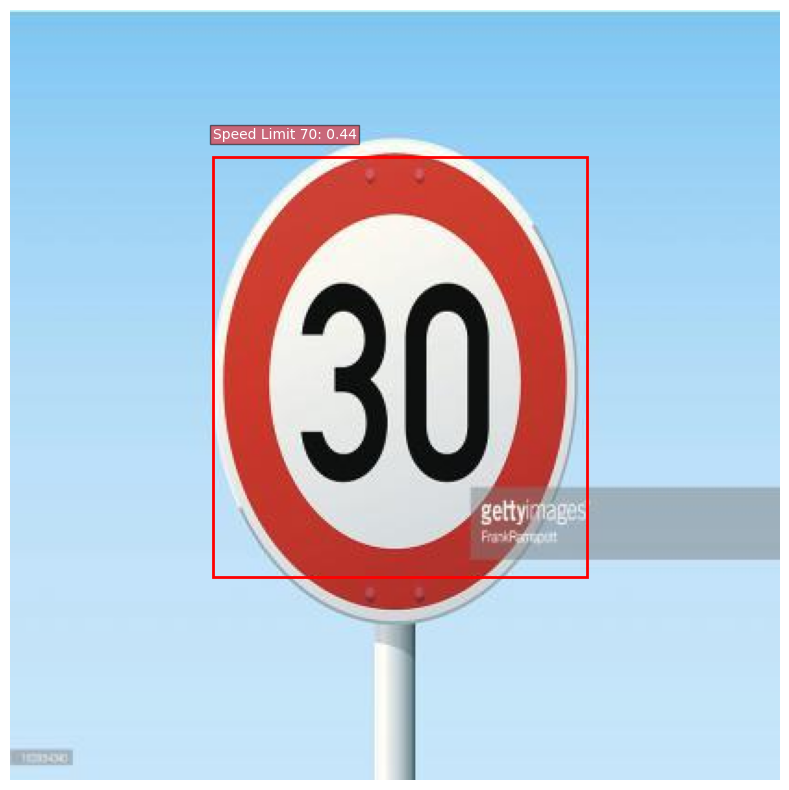

The time of execution of above program is: 0.3240501880645752 seconds


In [33]:
import os
import time
import torchvision
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Pick a test image automatically from dataset test split.
test_dir = os.path.join(root_dir, coco_dir, "test")
test_images = sorted(
    [f for f in os.listdir(test_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
 )
if not test_images:
    raise FileNotFoundError(f"No test images found in: {test_dir}")

img_path = os.path.join(test_dir, test_images[0])
input_image = cv2.imread(img_path)
if input_image is None:
    raise FileNotFoundError(f"Could not read image at: {img_path}")

score_threshold = 0.5
start = time.time()
duration, scores, labels, boxes = gtf.Predict(input_image, class_list, vis_threshold=score_threshold)

# Convert output tensors to CPU numpy for safe indexing.
scores = scores.detach().cpu().numpy()
labels = labels.detach().cpu().numpy()
boxes = boxes.detach().cpu().numpy()

# Filter detections by threshold.
indices = np.where(scores > score_threshold)[0]

if len(indices) == 0:
    print(f"No detections above threshold ({score_threshold}).")
else:
    _, ax = plt.subplots(1, figsize=(12, 8))
    ax.imshow(cv2.cvtColor(input_image, cv2.COLOR_BGR2RGB))

    for idx in indices:
        x1, y1, x2, y2 = boxes[idx].astype(int)
        width = x2 - x1
        height = y2 - y1
        rect = patches.Rectangle((x1, y1), width, height, linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)

        class_idx = int(labels[idx])
        class_name = class_list[class_idx] if 0 <= class_idx < len(class_list) else str(class_idx)
        score = scores[idx]
        ax.text(
            x1,
            max(0, y1 - 10),
            f"{class_name}: {score:.2f}",
            color='white',
            fontsize=10,
            bbox=dict(facecolor='red', alpha=0.5, pad=2)
        )

    ax.axis("off")
    plt.tight_layout()
    plt.show()

end = time.time()
print("The time of execution of above program is:", end - start, "seconds")

In [ ]:
!curl -s https://ngrok-agent.s3.amazonaws.com/ngrok.asc | sudo tee /etc/apt/trusted.gpg.d/ngrok.asc >/dev/null && echo "deb https://ngrok-agent.s3.amazonaws.com buster main" | sudo tee /etc/apt/sources.list.d/ngrok.list && sudo apt update && sudo apt install ngrok

how to get new authtoken?


Step 1: Go to the ngrok website by searching for "ngrok | Unified Application Delivery Platform for Developers" on Google.

Step 2: Sign up for ngrok using your email account and provide the necessary details.

Step 3: Navigate to the "Your Authtoken" section in your ngrok account settings, copy the token, and replace the existing token in the provided line of code (i.e., 24jMmkCh5Tr4hOZ9Dpg69QtTDSH_3n21SSxtBHr1F9QckcBzi).

In [ ]:
'''The first two commands install the pyngrok and flask-ngrok packages via pip, which are used for setting up secure tunnels to local servers for exposing them to the internet.
The third command sets the authentication token required for using ngrok, a service that creates secure tunnels from a public endpoint to a locally running web service,
facilitating testing and development of web applications.'''

# !pip install pyngrok
# !pip install --force-reinstall --ignore-installed blinker flask flask-ngrok

import os
ngrok_token = os.getenv("NGROK_AUTH_TOKEN", "")
if ngrok_token:
    !ngrok authtoken $ngrok_token
else:
    print("Set NGROK_AUTH_TOKEN environment variable first, then rerun this cell.")


Note: The following code will run continuously until manually stopped by the user. If Ngrok generates a new URL, it is important to handle it carefully, especially if predictions are required each time.

index.html


In [ ]:
# <!DOCTYPE html>
# <html lang="en">
# <head>
#     <meta charset="UTF-8">
#     <meta name="viewport" content="width=device-width, initial-scale=1.0">
#     <title>Traffic Sign Detection and Recognition</title>
#     <link href="https://fonts.googleapis.com/css2?family=Roboto:wght@400;500;700&display=swap" rel="stylesheet">
#     <style>
#         body {
#             font-family: 'Roboto', sans-serif;
#             background-color: #f4f4f9;
#             margin: 0;
#             padding: 0;
#             display: flex;
#             justify-content: center;
#             align-items: center;
#             height: 100vh;
#             color: #333;
#         }
#         .container {
#             background: #fff;
#             padding: 2rem;
#             border-radius: 10px;
#             box-shadow: 0 4px 6px rgba(0, 0, 0, 0.1);
#             width: 90%;
#             max-width: 600px;
#             text-align: center;
#         }
#         h1 {
#             font-size: 2rem;
#             color: #2c3e50;
#             margin-bottom: 1rem;
#         }
#         p {
#             color: #7f8c8d;
#             margin-bottom: 2rem;
#         }
#         input[type="file"] {
#             display: block;
#             margin: 1rem auto;
#             padding: 0.5rem;
#             border: 1px solid #bdc3c7;
#             border-radius: 5px;
#             font-size: 1rem;
#         }
#         button {
#             background-color: #2980b9;
#             color: white;
#             border: none;
#             padding: 0.8rem 1.5rem;
#             font-size: 1rem;
#             border-radius: 5px;
#             cursor: pointer;
#             transition: background-color 0.3s ease;
#         }
#         button:hover {
#             background-color: #1f5f87;
#         }
#         footer {
#             margin-top: 2rem;
#             font-size: 0.9rem;
#             color: #95a5a6;
#         }
#     </style>
# </head>
# <body>
#     <div class="container">
#         <h1>Traffic Sign Detection and Recognition</h1>
#         <p>Upload an image of a traffic sign, and our system will detect and recognize it with precision.</p>
#         <form action="/process" method="POST" enctype="multipart/form-data">
#             <input type="file" name="image" accept="image/*" required>
#             <button type="submit">Upload and Process</button>
#         </form>
#         <footer>
#             &copy; 2025 Traffic AI Solutions. All rights reserved.
#         </footer>
#     </div>
# </body>
# </html>


result.html

In [ ]:
# <!DOCTYPE html>
# <html lang="en">
# <head>
#     <meta charset="UTF-8">
#     <meta name="viewport" content="width=device-width, initial-scale=1.0">
#     <title>Traffic Sign Detection and Recognition Results</title>
#     <link href="https://fonts.googleapis.com/css2?family=Roboto:wght@400;500;700&display=swap" rel="stylesheet">
#     <style>
#         body {
#             font-family: 'Roboto', sans-serif;
#             background-color: #f4f4f9;
#             margin: 0;
#             padding: 0;
#             display: flex;
#             justify-content: center;
#             align-items: center;
#             flex-direction: column;
#             min-height: 100vh;
#             color: #333;
#         }
#         .container {
#             background: #fff;
#             padding: 2rem;
#             border-radius: 10px;
#             box-shadow: 0 4px 6px rgba(0, 0, 0, 0.1);
#             width: 90%;
#             max-width: 800px;
#             text-align: center;
#         }
#         h1 {
#             font-size: 2rem;
#             color: #2c3e50;
#             margin-bottom: 1rem;
#         }
#         h2 {
#             font-size: 1.5rem;
#             color: #34495e;
#             margin-top: 2rem;
#         }
#         ul {
#             list-style: none;
#             padding: 0;
#             margin: 1rem 0;
#         }
#         ul li {
#             font-size: 1.2rem;
#             color: #16a085;
#             margin: 0.5rem 0;
#         }
#         .image-container {
#             display: flex;
#             justify-content: space-evenly;
#             align-items: center;
#             margin-top: 1.5rem;
#         }
#         .image-container img {
#             width: 300px; /* Ensures both images are the same size */
#             height: auto;  /* Maintains aspect ratio */
#             border: 2px solid #bdc3c7;
#             border-radius: 8px;
#         }
#         footer {
#             margin-top: 2rem;
#             font-size: 0.9rem;
#             color: #95a5a6;
#         }
#     </style>
# </head>
# <body>
#     <div class="container">
#         <h1>Traffic Sign Detection and Recognition Results</h1>

#         <h2>Detected Classes:</h2>
#         <ul>
#             {% for class_name in class_names %}
#                 <li>{{ class_name }}</li>
#             {% endfor %}
#         </ul>

#         <h2>Images</h2>
#         <div class="image-container">
#             <div>
#                 <h3>Original Image</h3>
#                 <img src="{{ original_image }}" alt="Original Image">
#             </div>
#             <div>
#                 <h3>Processed Image</h3>
#                 <img src="{{ processed_image }}" alt="Processed Image">
#             </div>
#         </div>
#     </div>
#     <footer>
#         &copy; 2025 Traffic AI Solutions. Powered by Machine Learning.
#     </footer>
# </body>
# </html>


In [ ]:
from flask import Flask, request, render_template, url_for
from werkzeug.utils import secure_filename
from flask_ngrok import run_with_ngrok
import cv2
import os
import time
import torchvision
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pyngrok import ngrok

# Initialize Flask app
app = Flask(__name__)

# Define folders for uploads and processed images
UPLOAD_FOLDER = "static/uploads"
PROCESSED_FOLDER = "static/processed"
os.makedirs(UPLOAD_FOLDER, exist_ok=True)
os.makedirs(PROCESSED_FOLDER, exist_ok=True)

# Start ngrok
run_with_ngrok(app)  # Automatically start ngrok when the app runs

@app.route("/")
def index():
    """
    Renders the index page with the image upload form.
    """
    return render_template("index.html")  # HTML form for uploading images

@app.route("/process", methods=["POST"])
def process_image_route():
    """
    Handles image upload and processing.
    """
    if "image" not in request.files:
        return "No image file uploaded", 400

    image_file = request.files["image"]
    if image_file.filename == "":
        return "No selected file", 400

    # Save the uploaded image to the UPLOAD_FOLDER
    filename = secure_filename(image_file.filename)
    input_path = os.path.join(UPLOAD_FOLDER, filename)
    image_file.save(input_path)

    # Process the image
    class_names, output_image_filename = process_image(input_path)

    # Generate URLs for images to display in the template
    original_image_url = url_for("static", filename=f"uploads/{filename}")
    processed_image_url = url_for("static", filename=f"processed/{output_image_filename}")

    return render_template(
        "result.html",
        original_image=original_image_url,
        processed_image=processed_image_url,
        class_names=class_names
    )

def process_image(input_path):
    """
    Processes the input image, applies traffic sign detection, and saves the processed image.
    """
    # Load the image
    image = cv2.imread(input_path)
    start = time.time()

    # Example model predictions (replace with your model's logic)
    duration, scores, labels, boxes = gtf.Predict(image, class_list, vis_threshold=0.2)
    pred = {
        'boxes': boxes,
        'scores': scores,
        'labels': labels
    }

    def apply_nms(orig_prediction, iou_thresh=0.9):
        """
        Apply Non-Maximum Suppression (NMS) to filter overlapping bounding boxes.
        """
        keep = torchvision.ops.nms(orig_prediction['boxes'], orig_prediction['scores'], iou_thresh)
        final_prediction = orig_prediction
        final_prediction['boxes'] = final_prediction['boxes'][keep]
        final_prediction['scores'] = final_prediction['scores'][keep]
        final_prediction['labels'] = final_prediction['labels'][keep]
        return final_prediction

    # Apply NMS to predictions
    pred = apply_nms(pred, iou_thresh=0.9)

    # Keep only the prediction with the highest score
    max_score_idx = pred['scores'].argmax()
    final_boxes = [pred['boxes'][max_score_idx]]
    final_scores = [pred['scores'][max_score_idx]]
    final_labels = [pred['labels'][max_score_idx]]

    end = time.time()

    # Draw the single bounding box on the image
    plt.rcParams['text.color'] = 'blue'
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    ax.imshow(image_rgb)

    for (box, label, score) in zip(final_boxes, final_labels, final_scores):
        x, y, width, height = box[0], box[1], box[2] - box[0], box[3] - box[1]
        rect = patches.Rectangle((x, y), width, height, linewidth=2, edgecolor="r", facecolor="none")
        ax.add_patch(rect)
        ax.text(x, y - 10, f"{class_list[label]} ({score:.2f})", fontsize=10)

    # Save the processed image
    output_filename = f"processed_{os.path.basename(input_path)}"
    output_path = os.path.join(PROCESSED_FOLDER, output_filename)
    plt.savefig(output_path)
    plt.close()

    print(f"Processing time: {end - start:.2f} seconds")
    return [class_list[final_labels[0].item()]], output_filename
if __name__ == '__main__':
    port = "5000"
    # Open a ngrok tunnel to the HTTP server
    public_url = ngrok.connect(port).public_url
    print(f"Running on: {public_url}")
    app.run()



## YOLO Lightweight Path (Ultralytics)
Install YOLO and download a lightweight checkpoint for faster CPU experiments.

In [34]:
%pip install -q ultralytics

Note: you may need to restart the kernel to use updated packages.


In [35]:
from ultralytics import YOLO
import os

# Try requested checkpoint first; if unavailable, fallback to official nano models.
candidates = ["yolo26n.pt", "yolo11n.pt", "yolov8n.pt"]
yolo_model = None
selected_ckpt = None
last_error = None

for ckpt in candidates:
    try:
        yolo_model = YOLO(ckpt)
        selected_ckpt = ckpt
        break
    except Exception as e:
        last_error = str(e)

if yolo_model is None:
    raise RuntimeError(f"Could not load any YOLO checkpoint. Last error: {last_error}")

print(f"Loaded YOLO checkpoint: {selected_ckpt}")

# Quick CPU inference test on one image from test split.
test_dir = os.path.join(root_dir, coco_dir, "test")
img_files = sorted([f for f in os.listdir(test_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))])
if not img_files:
    raise FileNotFoundError(f"No test images found in {test_dir}")

test_img = os.path.join(test_dir, img_files[0])
results = yolo_model.predict(source=test_img, imgsz=320, device="cpu", conf=0.35, verbose=False)
print(f"YOLO inference done on: {test_img}")
print(f"Detections: {len(results[0].boxes) if results else 0}")

Loaded YOLO checkpoint: yolo26n.pt
YOLO inference done on: ./Self-Driving Cars.v6-version-4-prescan-416x416.coco/test/000003_jpg.rf.8511b9c219dbf9799a6d58900b15917d.jpg
Detections: 0


## YOLO Fine-Tuning Setup
Convert Roboflow COCO annotations to YOLO labels and create a YOLO-ready dataset structure.

In [4]:
import json
import shutil
import os
from collections import defaultdict
from pathlib import Path

# ==========================================
# 1. Configuration & Paths
# ==========================================
# Assuming these variables were set earlier in your workspace, or explicitly declare them here.
# For standalone execution, we configure the dataset paths:
import __main__
dataset_root = getattr(__main__, 'root_dir', '.')
dataset_folder = getattr(__main__, 'coco_dir', 'Self-Driving Cars.v6-version-4-prescan-416x416.coco')

SOURCE_ROOT = Path(dataset_root) / dataset_folder
YOLO_ROOT = Path("yolo_data")
DATASET_SPLITS = ["train", "valid", "test"]

def _safe_link_or_copy(src: Path, dst: Path):
    """
    Safely link or copy images.
    Uses symlinks where possible to save disk space and gracefully falls back to copy.
    """
    if dst.exists():
        return
    try:
        dst.symlink_to(src.resolve())
    except Exception:
        shutil.copy2(src, dst)

def _clamp_coordinate(val: float) -> float:
    """Clamps a normalized bounding box coordinate between 0.0 and 1.0."""
    return min(max(val, 0.0), 1.0)

def extract_categories(train_annotation_path: Path):
    """Parses the COCO JSON file to extract class names and map IDs."""
    with open(train_annotation_path, "r", encoding="utf-8") as file:
        coco_data = json.load(file)
    
    categories = sorted(coco_data["categories"], key=lambda c: c["id"])
    id_mapping = {c["id"]: index for index, c in enumerate(categories)}
    class_names = [c["name"] for c in categories]
    return id_mapping, class_names

def generate_yolo_yaml(target_dir: Path, class_names: list):
    """Generates the data.yaml file required by Ultralytics YOLO."""
    lines = [
        f"path: {target_dir.resolve()}",
        "train: images/train",
        "val: images/valid",
        "test: images/test",
        f"nc: {len(class_names)}",
        "names:"
    ]
    for idx, class_name in enumerate(class_names):
        lines.append(f"  {idx}: {class_name}")
        
    yaml_config_path = target_dir / "data.yaml"
    yaml_config_path.write_text("\n".join(lines), encoding="utf-8")

def process_dataset_split(split_name: str, src_dir: Path, tgt_dir: Path, id_mapping: dict):
    """Processes a single COCO dataset split and creates YOLO formatted txt files and images."""
    json_path = src_dir / split_name / "_annotations.coco.json"
    
    if not json_path.exists():
        print(f"[Warning] Annotation file not found for split '{split_name}': {json_path}")
        return 0, 0
        
    with open(json_path, "r", encoding="utf-8") as f:
        coco_data = json.load(f)

    # Map image configurations
    images_dict = {img["id"]: img for img in coco_data["images"]}
    
    # Map annotations to their corresponding images
    annotations_by_image = defaultdict(list)
    for ann in coco_data["annotations"]:
        if ann.get("iscrowd", 0) == 1:
            continue
        annotations_by_image[ann["image_id"]].append(ann)

    src_images_dir = src_dir / split_name
    dest_images_dir = tgt_dir / "images" / split_name
    dest_labels_dir = tgt_dir / "labels" / split_name

    successful_conversions = 0
    missing_files = 0

    for image_id, img_info in images_dict.items():
        filename = img_info["file_name"]
        src_img_file = src_images_dir / filename
        dst_img_file = dest_images_dir / filename

        if not src_img_file.exists():
            missing_files += 1
            continue

        _safe_link_or_copy(src_img_file, dst_img_file)

        img_width = float(img_info["width"])
        img_height = float(img_info["height"])

        yolo_annotations = []
        for ann in annotations_by_image.get(image_id, []):
            cat_id = ann["category_id"]
            if cat_id not in id_mapping:
                continue

            x, y, w, h = ann["bbox"]
            if w <= 0 or h <= 0:
                continue

            # Convert bbox from [x_min, y_min, width, height] to YOLO [x_center, y_center, width, height] normalized
            x_center = _clamp_coordinate((x + w / 2.0) / img_width)
            y_center = _clamp_coordinate((y + h / 2.0) / img_height)
            norm_width = _clamp_coordinate(w / img_width)
            norm_height = _clamp_coordinate(h / img_height)

            class_idx = id_mapping[cat_id]
            yolo_annotations.append(f"{class_idx} {x_center:.6f} {y_center:.6f} {norm_width:.6f} {norm_height:.6f}")

        # Save the .txt file with the annotations
        label_file = dest_labels_dir / f"{Path(filename).stem}.txt"
        label_file.write_text("\n".join(yolo_annotations), encoding="utf-8")
        successful_conversions += 1

    return successful_conversions, missing_files

# ==========================================
# 2. Execution Pipeline
# ==========================================
print("Initializing dataset conversion pipeline...")

# Clean up previously generated YOLO dataset to avert residual bugs
if YOLO_ROOT.exists():
    shutil.rmtree(YOLO_ROOT)

# Generate destination directory hierarchy
for split in DATASET_SPLITS:
    (YOLO_ROOT / "images" / split).mkdir(parents=True, exist_ok=True)
    (YOLO_ROOT / "labels" / split).mkdir(parents=True, exist_ok=True)

train_json_path = SOURCE_ROOT / "train" / "_annotations.coco.json"

if train_json_path.exists():
    class_id_map, discovered_classes = extract_categories(train_json_path)
    generate_yolo_yaml(YOLO_ROOT, discovered_classes)

    for split in DATASET_SPLITS:
        converted_count, missing_count = process_dataset_split(split, SOURCE_ROOT, YOLO_ROOT, class_id_map)
        print(f"Split '{split}': Successfully processed {converted_count} files (Missing: {missing_count})")

    print(f"\nYOLO configuration generated at: {(YOLO_ROOT / 'data.yaml').resolve()}")
    print(f"Total discovered classes: {len(discovered_classes)} -> {discovered_classes}")
else:
    print(f"[Warning] Source dataset does not exist at {train_json_path}. Please adjust configuration paths or download the dataset first.")

Initializing dataset conversion pipeline...
[Warning] Source dataset does not exist at Self-Driving Cars.v6-version-4-prescan-416x416.coco/train/_annotations.coco.json. Please adjust configuration paths or download the dataset first.


In [3]:
from ultralytics import YOLO

# -------- Training Config (CPU-friendly) --------
train_cfg = {
    "data": "yolo_data/data.yaml",
    "epochs": 20,
    "imgsz": 320,
    "batch": 8,
    "device": "cpu",
    "workers": 2,
    "project": "yolo_runs",
    "name": "traffic_sign_yolo26n",
    "pretrained": True,
    "exist_ok": True,
    "verbose": True,
}

model = YOLO("yolo26n.pt")
train_results = model.train(**train_cfg)

print("Training completed.")
print("Best checkpoint:", "runs/detect/yolo_runs/traffic_sign_yolo26n/weights/best.pt")

Ultralytics 8.4.22 🚀 Python-3.12.3 torch-2.10.0+cu128 CPU (AMD Ryzen 7 5800H with Radeon Graphics)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_data/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=traffic_sign_yolo26n, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patienc

RuntimeError: Dataset 'yolo_data/data.yaml' error ❌ 'yolo_data/data.yaml' does not exist

In [ ]:
import json
import shutil
from pathlib import Path
from ultralytics import YOLO

# -------- Inference Config --------
BEST_CKPT = Path("runs/detect/yolo_runs/traffic_sign_yolo26n/weights/best.pt")

base_dir = "."
dataset_name = "Self-Driving Cars.v6-version-4-prescan-416x416.coco"
TEST_DIR = Path(base_dir) / dataset_name / "test"

RESULTS_DIR = Path("results")
N_IMAGES = 5
CONF_THRES = 0.25

if not BEST_CKPT.exists():
    raise FileNotFoundError(f"best.pt not found at: {BEST_CKPT.resolve()}")
if not TEST_DIR.exists():
    raise FileNotFoundError(f"Test directory not found at: {TEST_DIR.resolve()}")

all_imgs = sorted([p for p in TEST_DIR.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png"}])
if len(all_imgs) < N_IMAGES:
    raise RuntimeError(f"Need at least {N_IMAGES} test images, found {len(all_imgs)}")
sample_imgs = all_imgs[:N_IMAGES]

# Keep output deterministic and clean each run.
if RESULTS_DIR.exists():
    shutil.rmtree(RESULTS_DIR)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

model = YOLO(str(BEST_CKPT))
results = model.predict(
    source=[str(p) for p in sample_imgs],
    imgsz=320,
    conf=CONF_THRES,
    device="cpu",
    save=True,
    project=".",
    name="results",
    exist_ok=True,
    verbose=False,
)

summary = []
print(f"Using checkpoint: {BEST_CKPT}")
for i, (img_path, r) in enumerate(zip(sample_imgs, results), start=1):
    det_count = len(r.boxes)
    summary.append({"image": img_path.name, "detections": int(det_count)})
    print(f"{i}. {img_path.name}: detections={det_count}")

summary_path = RESULTS_DIR / "summary.json"
summary_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")

print(f"Saved prediction images to: {RESULTS_DIR.resolve()}")
print(f"Saved summary file to: {summary_path.resolve()}")

Using checkpoint: runs/detect/yolo_runs/traffic_sign_yolo26n/weights/best.pt
Testing on:
- 000003_jpg.rf.8511b9c219dbf9799a6d58900b15917d.jpg
- 000006_jpg.rf.89610ec419ccfab22f8314026b90ee26.jpg
- 00000_00000_00003_png.rf.d18afc3c9625ffb1974029d3e3762aee.jpg
Results saved to /home/ali/Desktop/DigitalTechnologies/Computer_Vision/Driving-with-AI-Real-Time-Traffic-Sign-Detection-for-Safer-Navigation/runs/detect/yolo_runs_test/best_pt_inference
Total images processed: 3
Image 1: detections=1
Image 2: detections=2
Image 3: detections=1
Saved predictions under: yolo_runs_test/best_pt_inference
